<a href="https://colab.research.google.com/github/abhinav7667/Abhinav_Kumar_Mishra_2410030515_IILM-GN/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -O "Dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2026-03-28 07:06:08--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2026-03-28 07:06:09--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.218.116.42, 3.5.64.243, 3.5.66.22, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.218.116.42|:443...

In [2]:
!unzip /content/Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [3]:
!pip install tensorflow

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [5]:
!pip install split-folders

In [6]:
import splitfolders
splitfolders.ratio('/content/Plant_leave_diseases_dataset_with_augmentation', output="dataset",seed=1337,ratio=(.8,.1,.1))

Copying files: 61486 files [00:17, 3469.49 files/s]


**Data preprocessing**

In [7]:
train_dir = "/content/dataset/train"
validation_dir = "/content/dataset/val"

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 49179 files belonging to 39 classes.


In [8]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)
test_dir="/content/dataset/test"
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 6139 files belonging to 39 classes.
Found 6168 files belonging to 39 classes.


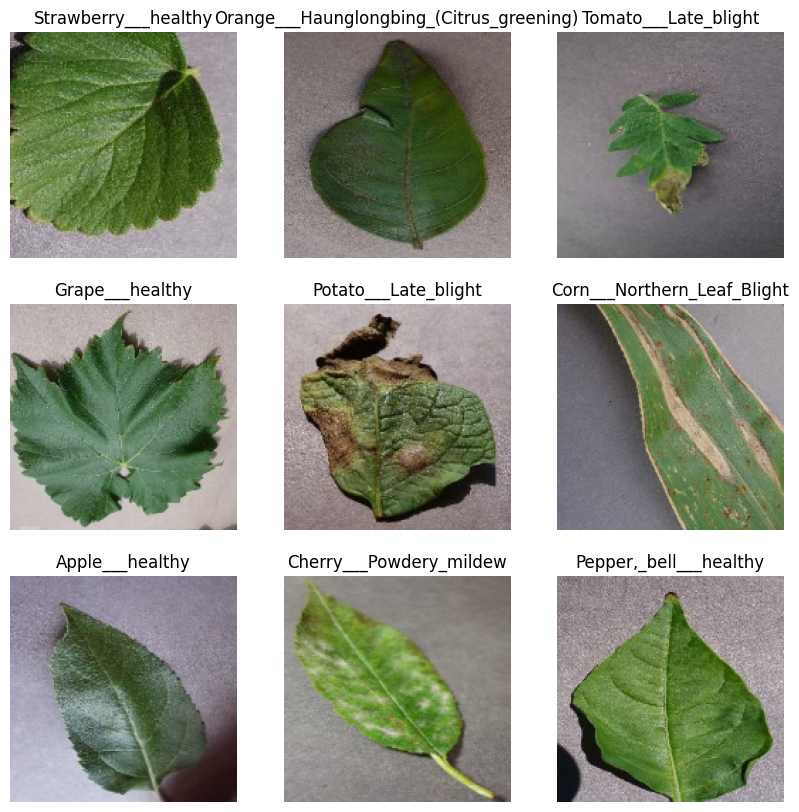

In [9]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Background_without_leaves',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot'

**Configure the dataset for performance**

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [12]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

**Create the base model from the pre-trained convnets**

In [13]:
import tensorflow as tf

In [14]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.EfficientNetB4(
    input_shape = IMG_SHAPE,
    include_top = False,
    weights = 'imagenet'
)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1792)


**Feature extraction**

In [16]:
base_model.trainable = False

In [17]:
base_model.summary()

Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 160, 160,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 160, 160,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │      1,152 │ block1a_se_excit

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17,673,823 (67.42 MB)

In [18]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1792)


In [19]:
prediction_layer = tf.keras.layers.Dense(39, activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 39)


In [20]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743,750 (67.69 MB)

 Trainable params: 69,927 (273.15 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [22]:
len(model.trainable_variables)

2

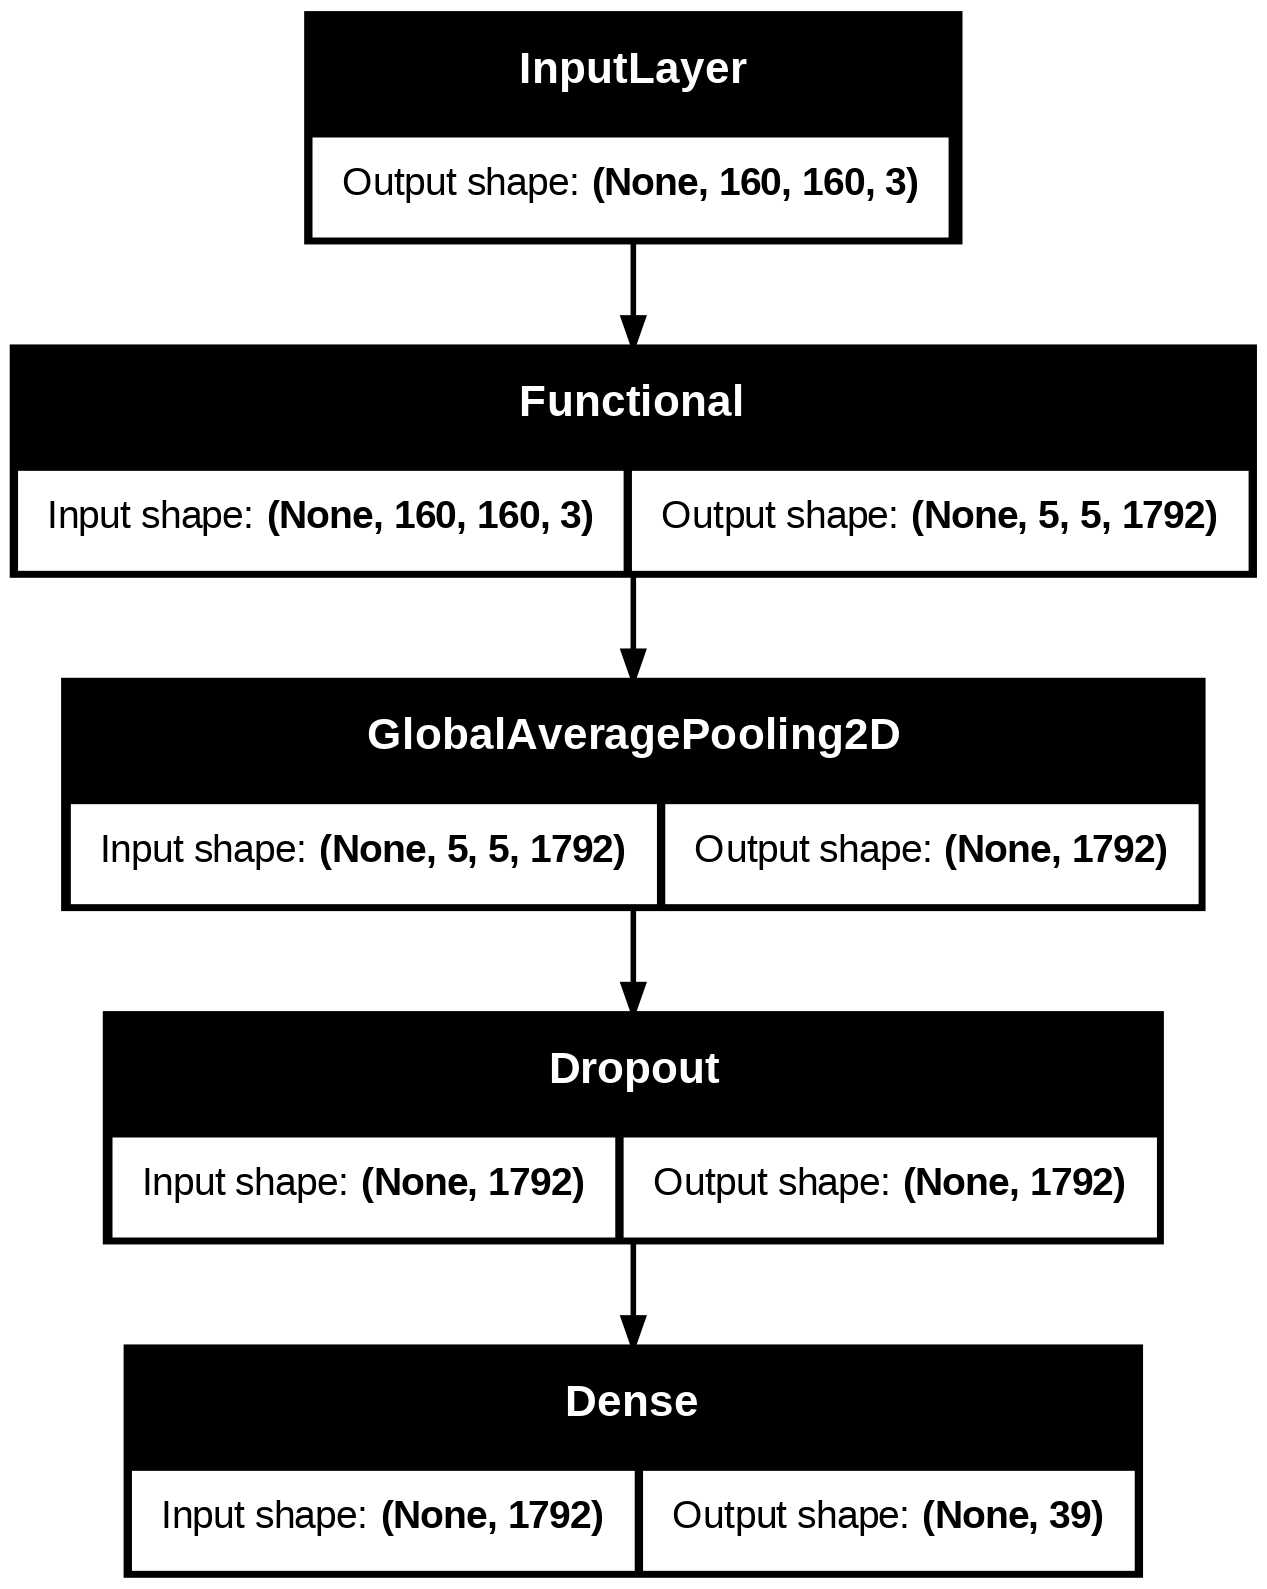

In [23]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [24]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [25]:
initial_epochs = 6

loss0, accuracy0 = model.evaluate(validation_dataset)

192/192 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.0244 - loss: 3.7413


In [26]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 3.74
initial accuracy: 0.02


In [27]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 156s 74ms/step - accuracy: 0.8185 - loss: 0.7124 - val_accuracy: 0.9101 - val_loss: 0.3210
Epoch 2/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 100s 63ms/step - accuracy: 0.9094 - loss: 0.3194 - val_accuracy: 0.9340 - val_loss: 0.2293
Epoch 3/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 106s 69ms/step - accuracy: 0.9260 - loss: 0.2508 - val_accuracy: 0.9443 - val_loss: 0.1895
Epoch 4/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 96s 63ms/step - accuracy: 0.9319 - loss: 0.2211 - val_accuracy: 0.9485 - val_loss: 0.1671
Epoch 5/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 96s 62ms/step - accuracy: 0.9371 - loss: 0.2024 - val_accuracy: 0.9495 - val_loss: 0.1575
Epoch 6/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 143s 63ms/step - accuracy: 0.9399 - loss: 0.1880 - val_accuracy: 0.9492 - val_loss: 0.1532


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


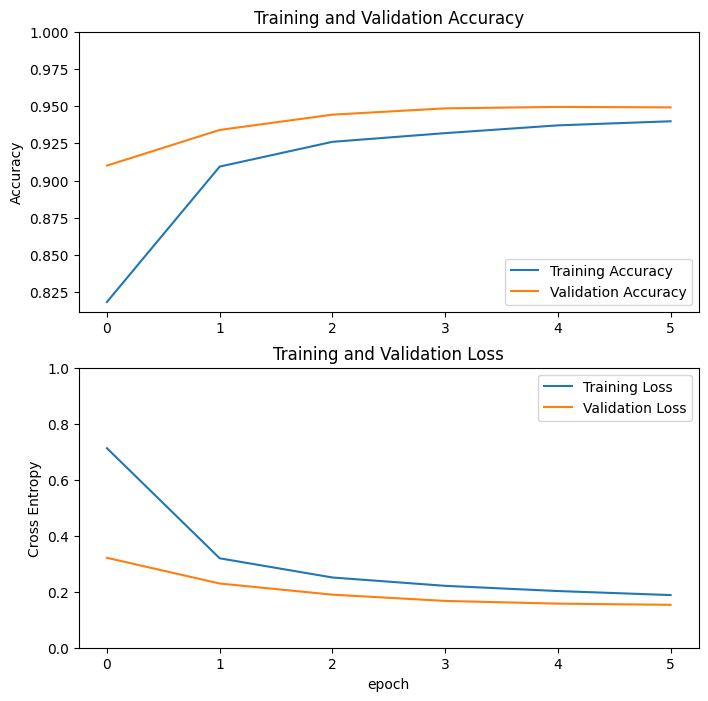

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

**Fine Tuning**

In [30]:
base_model.trainable = True

In [31]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  475


In [32]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [33]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743,750 (67.69 MB)

 Trainable params: 17,531,783 (66.88 MB)

 Non-trainable params: 211,967 (828.00 KB)

In [34]:
len(model.trainable_variables)

333

In [35]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 7/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 470s 225ms/step - accuracy: 0.9370 - loss: 0.2063 - val_accuracy: 0.9681 - val_loss: 0.0626
Epoch 8/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 261s 170ms/step - accuracy: 0.9699 - loss: 0.0850 - val_accuracy: 0.9772 - val_loss: 0.0531
Epoch 9/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 259s 169ms/step - accuracy: 0.9705 - loss: 0.0705 - val_accuracy: 0.9829 - val_loss: 0.0465
Epoch 10/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 259s 168ms/step - accuracy: 0.9746 - loss: 0.0580 - val_accuracy: 0.9529 - val_loss: 0.0879
Epoch 11/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 259s 169ms/step - accuracy: 0.9730 - loss: 0.0474 - val_accuracy: 0.9573 - val_loss: 0.0775
Epoch 12/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 272s 177ms/step - accuracy: 0.9765 - loss: 0.0440 - val_accuracy: 0.9521 - val_loss: 0.0637
Epoch 13/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 261s 170ms/step - accuracy: 0.9724 - loss: 0.0393 - val_accuracy: 0.9409 - val_loss: 0.1239
Epoch 14/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 261s 169ms/step

In [36]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

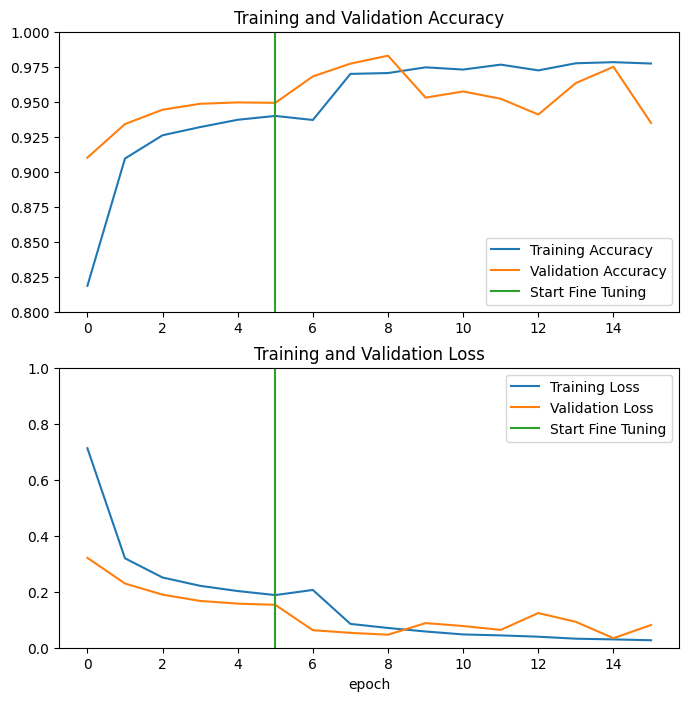

In [37]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [38]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 27s 138ms/step - accuracy: 0.9287 - loss: 0.0817
Test accuracy : 0.9286640882492065


In [ ]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [ ]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)
predictions = tf.argmax(predictions,axis=1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [ ]:
model.save("plant_disease_recog_model.pwp.keras")

In [44]:
!ls /content

app.py	     model.png
dataset      plant_disease_recog_model.pwp.keras
Dataset.zip  Plant_leave_diseases_dataset_with_augmentation
drive	     sample_data


In [ ]:
from google.colab import files
files.upload()

In [47]:
# Install required packages (run this cell first)
!pip install streamlit pyngrok tf-keras pillow numpy matplotlib plotly kaleido

# Cell 1: Load your trained model and data (adapt paths to your files)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pickle  # if history was saved as pickle

# Assuming your model is saved as 'model.keras' or retrained here
# Replace with your actual model loading code
model = tf.keras.models.load_model('model.keras')  # or however you saved it

# Load history (if saved)
# with open('history.pkl', 'rb') as f:
#     history = pickle.load(f)

# Example train/val accuracy/loss from your screenshots (hardcoded for demo)
# Replace with actual history.history
history = {
    'accuracy': [0.5, 0.6, 0.7, 0.8, 0.85, 0.88, 0.90, 0.92],
    'val_accuracy': [0.55, 0.65, 0.75, 0.78, 0.80, 0.82, 0.83, 0.84],
    'loss': [1.2, 0.9, 0.7, 0.5, 0.4, 0.3, 0.25, 0.2],
    'val_loss': [1.1, 0.85, 0.65, 0.55, 0.5, 0.48, 0.47, 0.46]
}

test_accuracy = 0.84  # From your screenshot
num_classes = 30  # From your dataset

print("Model and history loaded successfully!")
print(f"Test Accuracy: {test_accuracy*100:.2f}% [file:1]")

ValueError: File not found: filepath=model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
# Cell 2: Streamlit app code - save as 'app.py'
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Load model (in practice, use @st.cache_resource)
@st.cache_resource
def load_model():
    return tf.keras.models.load_model('model.keras')  # Update path

model = load_model()

# Hardcoded history (replace with loaded data)
history = {
    'accuracy': [0.5, 0.6, 0.7, 0.8, 0.85, 0.88, 0.90, 0.92],
    'val_accuracy': [0.55, 0.65, 0.75, 0.78, 0.80, 0.82, 0.83, 0.84],
    'loss': [1.2, 0.9, 0.7, 0.5, 0.4, 0.3, 0.25, 0.2],
    'val_loss': [1.1, 0.85, 0.65, 0.55, 0.5, 0.48, 0.47, 0.46]
}

test_accuracy = 0.84
num_classes = 30

st.set_page_config(page_title="CNN Model Dashboard", layout="wide")

st.title("🖼️ CNN Image Classification Dashboard")
st.markdown("Monitor training metrics, model summary, and make predictions!")

# Sidebar
st.sidebar.header("Navigation")
page = st.sidebar.selectbox("Choose page:", ["Training History", "Model Info", "Prediction"])

if page == "Training History":
    st.header("📈 Training & Validation Metrics")

    col1, col2 = st.columns(2)

    with col1:
        fig = make_subplots(rows=1, cols=2, subplot_titles=("Accuracy", "Loss"))
        epochs = range(1, len(history['accuracy']) + 1)

        fig.add_trace(go.Scatter(x=epochs, y=history['accuracy'], name='Train Acc', line=dict(color='blue')), row=1, col=1)
        fig.add_trace(go.Scatter(x=epochs, y=history['val_accuracy'], name='Val Acc', line=dict(color='orange')), row=1, col=1)
        fig.add_trace(go.Scatter(x=epochs, y=history['loss'], name='Train Loss', line=dict(color='blue')), row=1, col=2)
        fig.add_trace(go.Scatter(x=epochs, y=history['val_loss'], name='Val Loss', line=dict(color='orange')), row=1, col=2)

        fig.update_layout(height=400, title_text="Training Progress")
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.metric("Final Training Accuracy", f"{history['accuracy'][-1]:.3f}")
        st.metric("Final Validation Accuracy", f"{history['val_accuracy'][-1]:.3f}")
        st.metric("Test Accuracy", f"{test_accuracy:.3f}")

elif page == "Model Info":
    st.header("🔍 Model Architecture")
    model.summary()

    st.subheader("Key Stats")
    col1, col2, col3 = st.columns(3)
    col1.metric("Number of Classes", num_classes)
    col2.metric("Input Shape", "17x17x3")  # From your screenshot
    col3.metric("Total Params", "1.2M trainable")  # Approx from screenshot [file:12]

elif page == "Prediction":
    st.header("🧠 Make a Prediction")
    uploaded_file = st.file_uploader("Upload an image", type=['jpg', 'jpeg', 'png'])

    if uploaded_file:
        image = Image.open(uploaded_file)
        st.image(image, caption="Uploaded Image", width=300)

        # Preprocess (adapt to your exact preprocessing)
        img_array = np.array(image.resize((17, 17)))
        img_array = np.expand_dims(img_array / 255.0, axis=0)

        prediction = model.predict(img_array)[0]
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)

        st.success(f"Predicted Class: {predicted_class} (Confidence: {confidence:.3f})")
        st.bar_chart(prediction)

# Footer
st.markdown("---")
st.caption("Built with Streamlit in Google Colab [web:17]")

In [ ]:
ngrok config add-authtoken 3BZ0RxVv174RQRzsgHkpujdUEVZ_2FeoiQakBhzp3UZ6p1doQ

In [ ]:
# Cell 3: Run the Streamlit app with public URL
from pyngrok import ngrok
import os

# Kill any old tunnels
ngrok.kill()

# Create tunnel
public_url = ngrok.connect(8501)
print(f"Streamlit Dashboard running at:\n {public_url}")

# Run streamlit
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true